# Aperiodic exponent & aperiodic-corrected alpha power vs age

Standalone notebook after combined pipeline has successfully ran. **Press Run All.** It reuses your trained model (loaded from disk) and
recomputes, per subject, the posterior-ROI **aperiodic exponent**, **aperiodic offset**, and
**aperiodic-corrected alpha power** — quantities the original deploy computed internally but never
saved. It then plots each against age for the **large clinical** set (full range and restricted
20–70) and for **Dortmund**.

It loads the model files read-only and writes only
NEW files: `aperiodic_alpha_clinical_<tag>.csv`, `aperiodic_alpha_dortmund_<tag>.csv`, and the
figures. It does not run training, the connectivity deploy, or the Dortmund connectivity stage, and
it never writes `clinical_connectivity_*.csv` / `dortmund_connectivity_*.csv`.


In [ ]:
# MASTER CONFIG
EPOCH_LENGTH_SEC = 10
EPOCH_TAG = f"{EPOCH_LENGTH_SEC}s"
SFREQ = 200

TOP_N = 5


MAX_SUBJECTS_LARGE = None   # test run: cap the large clinical set (None = full 7020)
CONN_SCOPE = "roi"

MAX_SUBJECTS_DORTMUND = None
FORCE_FRESH = False

from pathlib import Path

EO_DIR        = Path(r"E:\Saxe_sandkasse\30EOEC_filer\Open_marked") 
EC_DIR        = Path(r"E:\Saxe_sandkasse\30EOEC_filer\Closed_marked")
MEDIUM_EDF_DIR= Path(r"G:\ChristianMusaeus\New_EEG\Clean_raw")     
LARGE_SET_DIR = Path(r"G:\ChristianMusaeus\Preprocessed_setfiles")  
LARGE_MAT_DIR = Path(r"G:\ChristianMusaeus\Data\eAsMat_15000-27193")   
DORTMUND_ROOT = Path(r"F:\Profdata") 
DORTMUND_SESSION = "ses-1"

META_PATHS = [
    Path(r"G:\ChristianMusaeus\EEG_sub_data_pseudoanonym.csv"),
    Path(r"G:\ChristianMusaeus\metadata_time_filtered.csv"),
]

OUT_ROOT      = Path(r"F:\Simonbachelorfiles")
PROCESSED_DIR = OUT_ROOT / "Processed"        
LABELING_DIR  = OUT_ROOT / "labeling"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
LABELING_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PKL    = OUT_ROOT / f"final_model_lr_{EPOCH_TAG}.pkl"
SCALER_PKL   = OUT_ROOT / f"final_scaler_lr_{EPOCH_TAG}.pkl"
IMPUTER_PKL  = OUT_ROOT / f"final_imputer_lr_{EPOCH_TAG}.pkl"
YTRUE_NPY    = OUT_ROOT / f"fooof_y_true_{EPOCH_TAG}.npy"
PROBEC_NPY   = OUT_ROOT / f"fooof_prob_ec_{EPOCH_TAG}.npy"
CHANNELS_NPY = OUT_ROOT / f"feature_channels_{EPOCH_TAG}.npy"
SUBJ_METRICS = OUT_ROOT / f"logreg_per_subject_metrics_{EPOCH_TAG}.csv"
MEDIUM_CSV   = LABELING_DIR / f"label_predictions_{EPOCH_TAG}.csv"
CLINICAL_CONN_CSV = OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv"
DORTMUND_CONN_CSV = OUT_ROOT / f"dortmund_connectivity_{EPOCH_TAG}.csv"

import mne, time, numpy as np, pandas as pd, re, os, math, csv
import warnings, joblib, random
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from scipy.io import loadmat
from scipy import stats

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    log_loss, roc_curve, auc, precision_recall_fscore_support
)

try:
    from specparam import SpectralModel
except ImportError:
    from fooof import FOOOF as SpectralModel

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="Lower-bound peak width")
mne.set_log_level('ERROR')

N_AGE_STRATA = 4
CV_RANDOM_SEED = 42
C_GRID = [0.01, 0.1, 0.2, 0.5, 1.0]
LOGREG_MAX_ITER = 2000

ALPHA_FREQ_RANGE = (3.0, 40.0)
ALPHA_PROFILE_RANGE = (4.0, 16.0)
ALPHA_RANGE = (4.0, 15.0)
ALPHA_BAND = (8.0, 13.0)   
TOTAL_BAND = (1.0, 40.0)
ALPHA_PROFILE_ROI = ["O1", "O2", "P3", "P4", "P7", "P8", "PZ"]
ROI_CHANNELS = ALPHA_PROFILE_ROI
POSTERIOR_FOR_SIMPLE = ALPHA_PROFILE_ROI 
FOOOF_SETTINGS = {
    "aperiodic_mode": "fixed", "peak_width_limits": (0.5, 12.0),
    "max_n_peaks": 6, "min_peak_height": 0.05, "peak_threshold": 2.0, "verbose": False,
}
FOOOF_SELECTED_FEATURES = ["offset", "exponent", "alpha_amp"]

TARGET_CHANNELS = [
    "EEG Fp1-REF", "EEG Fp2-REF", "EEG F3-REF", "EEG F4-REF", "EEG C3-REF",
    "EEG C4-REF", "EEG P3-REF", "EEG P4-REF", "EEG O1-REF", "EEG O2-REF",
    "EEG F7-REF", "EEG F8-REF", "EEG T7-REF", "EEG T8-REF", "EEG P7-REF",
    "EEG P8-REF", "EEG Fz-REF", "EEG Cz-REF", "EEG Pz-REF"
]


CH1_TO_1020_ORDER_19 = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2",
                        "F7","F8","T7","T8","P7","P8","Fz","Cz","Pz"]
_CH1_MAP = {f"CH{i+1}": CH1_TO_1020_ORDER_19[i].upper() for i in range(19)}

def canonical_channel_name(ch_name: str) -> str:
    name = str(ch_name).strip().upper()
    name = re.sub(r"^EEG\s+", "", name)
    name = re.sub(r"-REF$", "", name)
    name = re.sub(r"\s+", "", name)
    return _CH1_MAP.get(name, name) 

TARGET_CANONICAL = [canonical_channel_name(x) for x in TARGET_CHANNELS]

def calculate_psd(data, sfreq):
    n_per_seg = int(2.0 * sfreq)
    if n_per_seg > data.shape[-1]: n_per_seg = data.shape[-1]
    psds, freqs = mne.time_frequency.psd_array_welch(
        data, sfreq=sfreq, fmin=1.0, fmax=45.0,
        n_per_seg=n_per_seg, n_overlap=n_per_seg // 2,
        window="hann", average="mean", verbose=False)
    return psds, freqs

def build_alpha_profile(freqs, psd_cube, channels):
    roi_idx = [channels.index(ch) for ch in ALPHA_PROFILE_ROI if ch in channels]
    if not roi_idx: roi_idx = list(range(len(channels)))
    mean_spectrum = np.nanmean(psd_cube[:, roi_idx, :], axis=(0, 1))
    try:
        m = SpectralModel(**FOOOF_SETTINGS)
        lo, hi = ALPHA_PROFILE_RANGE
        m.fit(freqs, mean_spectrum, freq_range=(lo, hi))
        peaks = np.asarray(getattr(m, "peak_params_", []))
        if peaks.size > 0:
            if peaks.ndim == 1: peaks = peaks.reshape(1, -1)
            mask = (peaks[:, 0] >= lo) & (peaks[:, 0] <= hi)
            if np.any(mask):
                chosen = peaks[mask][np.argmax(peaks[mask][:, 1])]
                return float(chosen[0]), float(chosen[2])
    except Exception: pass
    return 0.0, 0.0

def compute_one_main_fooof(freqs, psd_cube, alpha_cf, alpha_bw):
    ap_s = dict(FOOOF_SETTINGS); ap_s["max_n_peaks"] = 0
    use_alpha = (alpha_bw > 0) and (alpha_cf > 0)
    sigma = (alpha_bw / 2.0) if use_alpha else 1.0
    features = []
    for epoch_psd in psd_cube:
        ef = []
        for spectrum in epoch_psd:
            offset, exponent, alpha_amp = 0.0, 0.0, 0.0
            try:
                fm = SpectralModel(**ap_s)
                fm.fit(freqs, spectrum, freq_range=ALPHA_FREQ_RANGE)
                if hasattr(fm, "aperiodic_params_") and len(fm.aperiodic_params_) >= 2:
                    offset, exponent = fm.aperiodic_params_[:2]
                if use_alpha:
                    model_fit = getattr(fm, "fooofed_spectrum_", None)
                    if model_fit is None:
                        model_fit = getattr(fm, "modeled_spectrum_", None)
                    ff  = getattr(fm, "freqs", None)
                    obs = getattr(fm, "power_spectrum", None) 
                    if model_fit is not None and ff is not None and obs is not None:
                        resid = np.asarray(obs) - np.asarray(model_fit)  
                        g = np.exp(-0.5 * ((np.asarray(ff) - alpha_cf) / sigma) ** 2)
                        denom = float(np.sum(g ** 2))
                        if denom > 0:
                            alpha_amp = max(float(np.sum(g * resid)) / denom, 0.0)
            except Exception:
                pass
            ef.extend([offset, exponent, alpha_cf, alpha_amp, alpha_bw])
        features.append(ef)
    return np.asarray(features, dtype=float)


def select_fooof_features(X_full, n_channels):
    base_order = ["offset", "exponent", "alpha_cf", "alpha_amp", "alpha_bw"]
    keep = []
    for ch in range(n_channels):
        base = ch * len(base_order)
        for fi, fn in enumerate(base_order):
            if fn in FOOOF_SELECTED_FEATURES: keep.append(base + fi)
    return X_full[:, keep]

def load_rejmanual(mat_path, n_epochs):
    try: mat = loadmat(str(mat_path), struct_as_record=False, squeeze_me=True)
    except: return None
    for accessor in [
        lambda: np.asarray(mat['EEG'].reject.rejmanual).ravel(),
        lambda: np.asarray(mat['reject'].rejmanual).ravel(),
    ]:
        try:
            v = accessor()
            if v.size == n_epochs: return v
        except: continue
    return None

def parse_subject_id(filepath):
    path = Path(filepath)
    for pattern in [r'(\d{5})_', r'label[01]_(\d+)', r'(\d+)']:
        m = re.search(pattern, path.stem)
        if m: return int(m.group(1))
    return abs(hash(path.stem)) % (10**7)

def calculate_roi_alpha_cf(epochs_data, sfreq, ch_names):
    roi_idx = [i for i, ch in enumerate(ch_names) if any(r in ch.upper() for r in ROI_CHANNELS)]
    if not roi_idx: roi_idx = list(range(len(ch_names)))
    n_per_seg = int(2.0 * sfreq)
    if n_per_seg > epochs_data.shape[-1]: n_per_seg = epochs_data.shape[-1]
    psds, freqs = mne.time_frequency.psd_array_welch(
        epochs_data, sfreq=sfreq, fmin=1.0, fmax=45.0,
        n_per_seg=n_per_seg, n_overlap=n_per_seg//2, window="hann", average="mean", verbose=False)
    mean_spectrum = np.nanmean(psds[:, roi_idx, :], axis=(0, 1))
    fm = SpectralModel(peak_width_limits=(0.5, 12.0), max_n_peaks=6, min_peak_height=0.05, verbose=False)
    try:
        fm.fit(freqs, mean_spectrum, freq_range=(3.0, 40.0))
        peaks = np.asarray(getattr(fm, "peak_params_", []))
        if peaks.size > 0:
            if peaks.ndim == 1: peaks = peaks.reshape(1, -1)
            mask = (peaks[:, 0] >= ALPHA_RANGE[0]) & (peaks[:, 0] <= ALPHA_RANGE[1])
            if np.any(mask): return float(peaks[mask][np.argmax(peaks[mask][:, 1])][0])
    except: pass
    return np.nan

def compute_connectivity_band(epochs_data, sfreq, fmin=ALPHA_BAND[0], fmax=ALPHA_BAND[1]):
    """Mean coherence (|Cxy|) and mean imaginary coherence (|Im(Cxy)|) over all unique
    channel pairs, averaged across the [fmin, fmax] band. Welch-style averaging across
    overlapping 2s segments pooled over the provided epochs."""
    if epochs_data.ndim != 3 or epochs_data.shape[0] == 0:
        return np.nan, np.nan
    n_epochs, n_ch, n_times = epochs_data.shape
    nperseg = min(int(2.0 * sfreq), n_times)
    if nperseg < 8:
        return np.nan, np.nan
    noverlap = nperseg // 2
    step = max(1, nperseg - noverlap)
    win = np.hanning(nperseg)
    freqs = np.fft.rfftfreq(nperseg, 1.0 / sfreq)
    band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    if band_idx.size == 0:
        return np.nan, np.nan
    csd_sum = np.zeros((band_idx.size, n_ch, n_ch), dtype=complex)
    n_segs = 0
    for ep in range(n_epochs):
        for st in range(0, n_times - nperseg + 1, step):
            seg = epochs_data[ep, :, st:st + nperseg] * win
            fftv = np.fft.rfft(seg, axis=1)[:, band_idx]     
            csd_sum += np.einsum('if,jf->fij', fftv, np.conj(fftv))
            n_segs += 1
    if n_segs == 0:
        return np.nan, np.nan
    csd_avg = csd_sum / n_segs
    iu = np.triu_indices(n_ch, k=1)
    coh_vals, imcoh_vals = [], []
    for fi in range(band_idx.size):
        S = csd_avg[fi]
        d = np.sqrt(np.abs(np.real(np.diag(S))))
        denom = np.outer(d, d)
        denom[denom == 0] = np.nan
        coh = np.abs(S) / denom        
        imcoh = np.abs(np.imag(S)) / denom  
        coh_vals.append(np.nanmean(coh[iu]))
        imcoh_vals.append(np.nanmean(imcoh[iu]))
    return float(np.nanmean(coh_vals)), float(np.nanmean(imcoh_vals))

def pick_montage_indices(ch_names):
    """Return indices of the 19-channel 10-20 montage within ch_names (canonical match)."""
    canon = [canonical_channel_name(c) for c in ch_names]
    idx = [canon.index(t) for t in TARGET_CANONICAL if t in canon]
    return idx

def pick_roi_indices(ch_names):
    """Indices of the posterior ROI (O1,O2,P3,P4,P7,P8,Pz) within ch_names.
    Connectivity is restricted to these; the classifier still uses all channels."""
    canon = [canonical_channel_name(c) for c in ch_names]
    roi = [r.upper() for r in ROI_CHANNELS]
    return [canon.index(t) for t in roi if t in canon]

def apply_conn_scope(df, scope=None):
    """Alias the chosen connectivity scope to the generic coh_*/imcoh_* columns used by the plots
    and stats. Both "roi" and "all" are stored in the CSV; this just selects which one the analysis
    uses (switch CONN_SCOPE and re-run the analysis cells, no need to re-deploy). Backward-compatible."""
    sc = scope or CONN_SCOPE
    for base in ["coh_ec","coh_eo","imcoh_ec","imcoh_eo"]:
        col = f"{base}_{sc}"
        if col in df.columns: df[base] = df[col]
    return df

age_dict = {}
for p in META_PATHS:
    if not p.exists():
        continue
    try:
        best_df = None
        for sep in [';', ',', '\t']:
            try:
                df_try = pd.read_csv(p, sep=sep, engine='python')
                if best_df is None or len(df_try.columns) > len(best_df.columns):
                    best_df = df_try
            except: pass
        if best_df is None or len(best_df.columns) < 2:
            print(f"  WARNING: could not parse {p.name}"); continue
        df_m = best_df
        df_m.rename(columns={df_m.columns[0]: 'subject_id'}, inplace=True)
        df_m.columns = [str(c).strip().lower() for c in df_m.columns]
        if 'y' in df_m.columns: df_m.rename(columns={'y': 'age'}, inplace=True)
        if 'age' not in df_m.columns:
            print(f"  WARNING: no age column in {p.name}: {df_m.columns.tolist()}"); continue
        df_m['subject_id'] = df_m['subject_id'].astype(str).str.extract(r'(\d+)').astype(float)
        before = len(age_dict)
        for _, row in df_m.iterrows():
            try: age_dict[int(row['subject_id'])] = float(row['age'])
            except: pass
        print(f"  Loaded {p.name}: +{len(age_dict)-before} entries (total {len(age_dict)})")
    except Exception as e:
        print(f"  Error loading {p.name}: {e}")


def _regplot_two(ax, df, ycol_ec, ycol_eo, ylabel, title):
    """Two regression lines (EC green, EO blue) of y vs age, with r/p annotation."""
    out = {}
    for cond, ycol, color in [("EC", ycol_ec, "#2ecc71"), ("EO", ycol_eo, "#3498db")]:
        d = df.dropna(subset=["age", ycol])
        if len(d) > 2:
            sns.regplot(data=d, x="age", y=ycol, ax=ax, color=color, label=cond,
                        scatter_kws={"alpha":0.35,"s":25,"edgecolor":"none"},
                        line_kws={"linewidth":3})
            if d["age"].nunique() > 1:
                try:
                    sl, ic, r, p, se = stats.linregress(d["age"], d[ycol])
                    out[cond] = (r, p, sl, len(d))
                except Exception:
                    pass
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Age"); ax.set_ylabel(ylabel); ax.legend()
    txt = "\n".join([f"{c}: r={v[0]:.2f}, p={v[1]:.1e}" for c, v in out.items()])
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    return out

def _regplot_metrics(ax, df, age, coh_col, imcoh_col, title):
    """EC-only: alpha coherence vs imaginary coherence, both vs age."""
    out = {}
    for label, col, color in [("Alpha coherence", coh_col, "#e74c3c"), ("Imaginary coherence", imcoh_col, "#9b59b6")]:
        d = df.dropna(subset=["age", col])
        if len(d) > 2:
            sns.regplot(data=d, x="age", y=col, ax=ax, color=color, label=label,
                        scatter_kws={"alpha":0.35,"s":25,"edgecolor":"none"},
                        line_kws={"linewidth":3})
            if d["age"].nunique() > 1:
                try:
                    sl, ic, r, p, se = stats.linregress(d["age"], d[col])
                    out[label] = (r, p, sl, len(d))
                except Exception:
                    pass
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Age"); ax.set_ylabel("Connectivity (EC)"); ax.legend()
    txt = "\n".join([f"{c.split()[0]}: r={v[0]:.2f}, p={v[1]:.1e}" for c, v in out.items()])
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    return out

def make_three_plots(df, suptitle):
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)); plt.subplots_adjust(wspace=0.3)
    s1 = _regplot_two(axes[0], df, "coh_ec", "coh_eo", "Alpha coherence", "1. Alpha coherence vs Age (EC vs EO)")
    s2 = _regplot_two(axes[1], df, "imcoh_ec", "imcoh_eo", "Imaginary coherence", "2. Imaginary coherence vs Age (EC vs EO)")
    s3 = _regplot_metrics(axes[2], df, "age", "coh_ec", "imcoh_ec", "3. EC: Alpha vs Imaginary coherence")
    plt.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.03)
    plt.show()
    return s1, s2, s3

def ec_eo_tests(df, label):
    """Paired EC vs EO tests + age-trend tests for both conditions and both metrics."""
    print(f"\n{'='*60}\nSTATISTICAL TESTS: {label}\n{'='*60}")
    for metric, ec_col, eo_col in [("Alpha coherence","coh_ec","coh_eo"),
                                    ("Imaginary coherence","imcoh_ec","imcoh_eo")]:
        d = df.dropna(subset=[ec_col, eo_col])
        if len(d) > 2:
            try:
                w_stat, w_p = stats.wilcoxon(d[ec_col], d[eo_col])
            except Exception:
                w_stat, w_p = np.nan, np.nan
            print(f"\n{metric} — EC vs EO (paired Wilcoxon, N={len(d)}):")
            print(f"  EC mean={d[ec_col].mean():.4f}, EO mean={d[eo_col].mean():.4f}")
            print(f"  W={w_stat:.1f}, p={w_p:.3e}  ->  {'SIGNIFICANT' if w_p < 0.05 else 'not significant'}")
            for cond, col in [("EC", ec_col), ("EO", eo_col)]:
                dd = df.dropna(subset=["age", col])
                if len(dd) > 2:
                    sl, ic, r, p, se = stats.linregress(dd["age"], dd[col])
                    print(f"  {cond} vs age: slope={sl:.5f}, r={r:.3f}, p={p:.3e}")
print(f"\nConfig loaded. EPOCH_LENGTH={EPOCH_LENGTH_SEC}s, TOP_N={TOP_N}")
print(f"Age data: {len(age_dict)} subjects")
print(f"Output root: {OUT_ROOT}")

  Loaded EEG_sub_data_pseudoanonym.csv: +100 entries (total 100)
  Loaded metadata_time_filtered.csv: +5777 entries (total 5877)

Config loaded. EPOCH_LENGTH=10s, TOP_N=5
Age data: 5877 subjects
Output root: F:\Simonbachelorfiles


In [ ]:

APERIODIC_CLINICAL_CSV = OUT_ROOT / f"aperiodic_alpha_clinical_{EPOCH_TAG}.csv"
APERIODIC_DORTMUND_CSV = OUT_ROOT / f"aperiodic_alpha_dortmund_{EPOCH_TAG}.csv"

TEST_N = None

print("Will write (new files only):")
print("  ", APERIODIC_CLINICAL_CSV)
print("  ", APERIODIC_DORTMUND_CSV)
print(f"TEST_N = {TEST_N}   (set to None for the full run)")

Will write (new files only):
   F:\Simonbachelorfiles\aperiodic_alpha_clinical_10s.csv
   F:\Simonbachelorfiles\aperiodic_alpha_dortmund_10s.csv
TEST_N = None   (set to None for the full run)


## A) Large clinical — aperiodic exponent / offset + alpha power per subject

In [ ]:
print(f"\n{'='*60}\nA) LARGE CLINICAL: aperiodic exponent/offset + alpha power per subject ({EPOCH_TAG})\n{'='*60}")
imputer = joblib.load(IMPUTER_PKL); scaler = joblib.load(SCALER_PKL); model = joblib.load(MODEL_PKL)
fch = [canonical_channel_name(c) for c in np.load(CHANNELS_NPY, allow_pickle=True)]

mat_files = sorted(LARGE_MAT_DIR.glob("*.mat"))
if TEST_N is not None:
    mat_files = mat_files[:TEST_N]
print(f"Processing {len(mat_files)} .mat files (TEST_N={TEST_N}).")
print("EC = epochs the classifier labels eyes-closed (P(EC) >= 0.5); EO = the rest.")
print("Per subject: mean over the posterior ROI (O1,O2,P3,P4,P7,P8,Pz) of the FOOOF offset,")
print("exponent and aperiodic-corrected alpha amplitude, for EC and EO separately.\n")

AP_FIELDS = ["subject","age","sex",
             "exponent_ec","offset_ec","alpha_power_ec",
             "exponent_eo","offset_eo","alpha_power_eo",
             "alpha_cf","n_ec","n_eo","n_epochs","n_roi_ch"]

def _get_age_sex(EEG):
    pid = getattr(EEG, "patientID", None)
    age = np.nan; sex = ""
    if pid is not None:
        try: age = float(getattr(pid, "age", np.nan))
        except Exception: age = np.nan
        s = str(getattr(pid, "sex", "")).strip().upper()
        sex = "F" if s.startswith("F") else ("M" if s.startswith("M") else "")
    if not (np.isfinite(age) and 0 < age < 120): age = np.nan
    return age, sex

def _load_large_mat(path):
    mm = loadmat(str(path), squeeze_me=True, struct_as_record=False)
    EEG = mm["EEG"] if "EEG" in mm else mm
    data = np.asarray(EEG.data, dtype=float)
    if data.ndim != 2: raise ValueError("not continuous 2D data")
    if data.shape[0] > data.shape[1]: data = data.T
    sr_native = float(getattr(EEG, "sr", getattr(EEG, "srate", SFREQ)))
    labels = [str(c.labels) for c in np.atleast_1d(EEG.chanlocs)]
    if np.nanmedian(np.nanstd(data, axis=1)) > 1e-3: data = data * 1e-6
    age, sex = _get_age_sex(EEG)
    bad_native = np.isnan(data).any(axis=0)
    if bad_native.any():
        for ci in range(data.shape[0]):
            v = data[ci]; m = np.isnan(v); gi = np.flatnonzero(~m)
            if m.any() and gi.size >= 2: v[m] = np.interp(np.flatnonzero(m), gi, v[gi])
            elif m.any(): v[m] = 0.0
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    info = mne.create_info(labels, sr_native, ch_types="eeg")
    raw = mne.io.RawArray(data, info, verbose="ERROR")
    raw.rename_channels({ch: canonical_channel_name(ch) for ch in raw.ch_names})
    raw.resample(SFREQ); raw.filter(1.0, 70.0, verbose="ERROR"); raw.notch_filter(50, verbose="ERROR")
    midx_raw = pick_montage_indices(raw.ch_names)
    if len(midx_raw) >= 2:
        raw.pick([raw.ch_names[k] for k in midx_raw])
    return raw, age, sex, bad_native, sr_native

done_sids = set()
if APERIODIC_CLINICAL_CSV.exists():
    try: done_sids = set(int(s) for s in pd.read_csv(APERIODIC_CLINICAL_CSV)["subject"].dropna().tolist())
    except Exception: done_sids = set()
if done_sids: print(f"Resume: {len(done_sids)} subjects already done will be skipped\n")

t0 = time.time(); n_kept = len(done_sids); skips = Counter()
_resume = len(done_sids) > 0 and APERIODIC_CLINICAL_CSV.exists()
with open(APERIODIC_CLINICAL_CSV, "a" if _resume else "w", newline="", encoding="utf-8") as fout:
    writer = csv.DictWriter(fout, fieldnames=AP_FIELDS)
    if not _resume: writer.writeheader(); fout.flush()

    for i, fp in enumerate(mat_files, 1):
        mt = re.search(r"(\d{3,})", fp.stem); sid = int(mt.group(1)) if mt else i
        if sid in done_sids: continue
        status = "kept"; t_sub = time.time(); n_valid = 0; age = np.nan; n_ec = 0; n_eo = 0
        try:
            raw, age, sex, bad_native, sr_native = _load_large_mat(fp)
            sfreq = raw.info["sfreq"]; chs = list(raw.ch_names)
            events = mne.make_fixed_length_events(raw, duration=EPOCH_LENGTH_SEC)
            ep = mne.Epochs(raw, events, tmin=0.0, tmax=EPOCH_LENGTH_SEC - 1.0/SFREQ,
                            baseline=None, preload=True, verbose="ERROR")
            data = ep.get_data(); onset_sec = ep.events[:,0] / SFREQ; del raw

            if i == 1:
                _midx = pick_montage_indices(chs); _ridx = pick_roi_indices(chs)
                print(f"  [diagnostic] first file: {len(chs)} ch, montage {len(_midx)}/19, ROI {len(_ridx)}/7, "
                      f"age={age}, NaN frac={bad_native.mean()*100:.2f}%, n_epochs(pre-valid)={data.shape[0]}\n")

            nan_overlap = np.zeros(len(onset_sec), bool)
            if bad_native.any():
                for j, t0s in enumerate(onset_sec):
                    a = int(round(t0s*sr_native)); b = int(round((t0s+EPOCH_LENGTH_SEC)*sr_native))
                    seg = bad_native[max(0,a):max(0,b)]
                    if seg.size and seg.any(): nan_overlap[j] = True
            valid = (~np.isnan(data).any(axis=(1,2))) & (np.var(data, axis=(1,2)) > 0) & (~nan_overlap)
            n_valid = int(valid.sum())
            if n_valid < 4:
                skips["too_few_valid_epochs"] += 1; status = "skip:too_few_valid_epochs"; raise StopIteration
            data = data[valid]

            psd_c, freqs = calculate_psd(data, sfreq)
            acf, abw = build_alpha_profile(freqs, psd_c, chs)
            fX = compute_one_main_fooof(freqs, psd_c, acf, abw) 

            aX = np.zeros((fX.shape[0], len(fch)*3))
            for ei in range(fX.shape[0]):
                col = 0
                for ch in fch:
                    try:
                        sb = chs.index(ch)*5
                        aX[ei, col] = fX[ei, sb]; aX[ei, col+1] = fX[ei, sb+1]; aX[ei, col+2] = fX[ei, sb+3]
                    except ValueError: pass
                    col += 3
            p_ec = model.predict_proba(scaler.transform(imputer.transform(aX)))[:, 1]
            ec_idx = np.where(p_ec >= 0.5)[0]; eo_idx = np.where(p_ec < 0.5)[0]
            n_ec = int(len(ec_idx)); n_eo = int(len(eo_idx))

            ridx = pick_roi_indices(chs)
            off_cols = [c*5+0 for c in ridx]; exp_cols = [c*5+1 for c in ridx]; amp_cols = [c*5+3 for c in ridx]
            def _means(idx):
                if len(ridx) >= 1 and len(idx) >= 1:
                    return (float(np.nanmean(fX[np.ix_(idx, exp_cols)])),
                            float(np.nanmean(fX[np.ix_(idx, off_cols)])),
                            float(np.nanmean(fX[np.ix_(idx, amp_cols)])))
                return np.nan, np.nan, np.nan
            exp_ec, off_ec, amp_ec = _means(ec_idx)
            exp_eo, off_eo, amp_eo = _means(eo_idx)

            if len(ridx) >= 2 and n_ec >= 1:
                alpha_cf = calculate_roi_alpha_cf(data[np.ix_(ec_idx, ridx)], sfreq, [chs[k] for k in ridx])
            else:
                alpha_cf = np.nan
            if len(ridx) < 1:
                skips["no_roi_ch"] += 1; status = "kept(roi=nan)"

            writer.writerow({"subject":sid, "age":age, "sex":sex,
                             "exponent_ec":exp_ec, "offset_ec":off_ec, "alpha_power_ec":amp_ec,
                             "exponent_eo":exp_eo, "offset_eo":off_eo, "alpha_power_eo":amp_eo,
                             "alpha_cf":alpha_cf, "n_ec":n_ec, "n_eo":n_eo,
                             "n_epochs":n_valid, "n_roi_ch":len(ridx)})
            fout.flush(); done_sids.add(sid); n_kept += 1

        except StopIteration:
            pass
        except Exception as e:
            skips[f"error:{type(e).__name__}"] += 1; status = f"ERROR:{type(e).__name__}:{str(e)[:60]}"

        if status.startswith("kept"):
            print(f"  [{i}/{len(mat_files)}] {fp.stem}: kept | age={age} | EC={n_ec}/EO={n_eo} | "
                  f"{time.time()-t_sub:.0f}s ({n_kept} total, {(time.time()-t0)/60:.1f} min)")
        else:
            print(f"  [{i}/{len(mat_files)}] {fp.stem}: {status}")

print(f"\nDone. {n_kept} subjects -> {APERIODIC_CLINICAL_CSV}")
if skips:
    print("Skips/issues:")
    for k, v in skips.most_common(): print(f"  {k}: {v}")


A) LARGE CLINICAL: aperiodic exponent/offset + alpha power per subject (10s)
Processing 7020 .mat files (TEST_N=None).
EC = epochs the classifier labels eyes-closed (P(EC) >= 0.5); EO = the rest.
Per subject: mean over the posterior ROI (O1,O2,P3,P4,P7,P8,Pz) of the FOOOF offset,
exponent and aperiodic-corrected alpha amplitude, for EC and EO separately.

Resume: 6859 subjects already done will be skipped

  [668/7020] 15777: skip:too_few_valid_epochs
  [674/7020] 15783: ERROR:ValueError:No events produced, check the values of start, stop, and dur
  [706/7020] 15820: skip:too_few_valid_epochs
  [1005/7020] 16189: ERROR:ValueError:No events produced, check the values of start, stop, and dur
  [1046/7020] 16262: skip:too_few_valid_epochs
  [1047/7020] 16263: skip:too_few_valid_epochs
  [1195/7020] 16489: ERROR:AttributeError:'dict' object has no attribute 'data'
  [1202/7020] 16496: skip:too_few_valid_epochs
  [1279/7020] 16642: ERROR:AttributeError:'dict' object has no attribute 'data'

## B) Dortmund — aperiodic exponent / offset + alpha power per subject

In [ ]:
print(f"\n{'='*60}\nB) DORTMUND: aperiodic exponent/offset + alpha power per subject ({EPOCH_TAG})\n{'='*60}")

parts_file = None
_cands = [DORTMUND_ROOT/"participants.tsv", DORTMUND_ROOT.parent/"participants.tsv",
          DORTMUND_ROOT.parent/"Dortmund"/"participants.tsv", DORTMUND_ROOT.parent/"Profdataset"/"participants.tsv"]
for cand in _cands:
    if cand.exists(): parts_file = cand; break
if parts_file is None:
    for base in [DORTMUND_ROOT, DORTMUND_ROOT.parent]:
        hits = list(base.rglob("participants.tsv"))
        if hits: parts_file = hits[0]; break
df_parts = None
if parts_file is not None:
    df_parts = pd.read_csv(parts_file, sep="\t")
    df_parts.columns = [str(c).strip().lower() for c in df_parts.columns]
    pid = next((c for c in df_parts.columns if "participant" in c), df_parts.columns[0])
    agec = next((c for c in df_parts.columns if "age" in c), None)
    df_parts["subject_num"] = df_parts[pid].astype(str).str.extract(r"(\d+)").astype(float)
    if agec: df_parts["age"] = pd.to_numeric(df_parts[agec], errors="coerce")
    print(f"participants.tsv: {len(df_parts)} rows")

sub_dirs = sorted([d for d in DORTMUND_ROOT.iterdir() if d.is_dir() and d.name.startswith("sub-")])
if TEST_N is not None:
    sub_dirs = sub_dirs[:TEST_N]
print(f"Processing {len(sub_dirs)} Dortmund subjects. EC = eyesclosed recordings, EO = eyesopen (known labels).\n")

AP_FIELDS_D = ["subject","subject_num","age",
               "exponent_ec","offset_ec","alpha_power_ec",
               "exponent_eo","offset_eo","alpha_power_eo",
               "alpha_cf","n_ec","n_eo"]

def _roi_fooof_means(data, chs):
    """Mean posterior-ROI aperiodic exponent/offset and aperiodic-corrected alpha power over given epochs."""
    if data.shape[0] < 1: return np.nan, np.nan, np.nan
    psd_c, freqs = calculate_psd(data, SFREQ)
    acf, abw = build_alpha_profile(freqs, psd_c, list(chs))
    fX = compute_one_main_fooof(freqs, psd_c, acf, abw)
    ridx = pick_roi_indices(list(chs))
    if len(ridx) < 1: return np.nan, np.nan, np.nan
    exp_cols=[c*5+1 for c in ridx]; off_cols=[c*5+0 for c in ridx]; amp_cols=[c*5+3 for c in ridx]
    return (float(np.nanmean(fX[:, exp_cols])), float(np.nanmean(fX[:, off_cols])), float(np.nanmean(fX[:, amp_cols])))

done_subnums = set()
if APERIODIC_DORTMUND_CSV.exists():
    try: done_subnums = set(int(s) for s in pd.read_csv(APERIODIC_DORTMUND_CSV)["subject_num"].dropna().tolist())
    except Exception: done_subnums = set()
if done_subnums: print(f"Resume: {len(done_subnums)} done will be skipped\n")

t0 = time.time(); n_kept = len(done_subnums)
_resume = len(done_subnums) > 0 and APERIODIC_DORTMUND_CSV.exists()
_fout = open(APERIODIC_DORTMUND_CSV, "a" if _resume else "w", newline="", encoding="utf-8")
_w = csv.DictWriter(_fout, fieldnames=AP_FIELDS_D)
if not _resume: _w.writeheader(); _fout.flush()

for si, sd in enumerate(sub_dirs, 1):
    sub = sd.name; sub_num = int(re.search(r"(\d+)", sub).group(1))
    if sub_num in done_subnums: continue
    eeg_dir = sd / DORTMUND_SESSION / "eeg"
    if not eeg_dir.exists(): eeg_dir = sd / "eeg"
    if not eeg_dir.exists(): continue
    ec_list, eo_list, chs_ref = [], [], None
    try:
        for fif in sorted(eeg_dir.glob("*_raw.fif")):
            fn = fif.stem.lower()
            if "acq-post" in fn: continue
            if "eyesclosed" in fn: bucket = "EC"
            elif "eyesopen" in fn: bucket = "EO"
            else: continue
            raw = mne.io.read_raw_fif(str(fif), preload=True, verbose="ERROR")
            midx = pick_montage_indices(raw.ch_names)
            if len(midx) < 5: continue
            raw.pick([raw.ch_names[k] for k in midx])
            raw.set_eeg_reference("average", projection=False, verbose="ERROR")
            events = mne.make_fixed_length_events(raw, duration=float(EPOCH_LENGTH_SEC))
            if len(events) == 0: continue
            epochs = mne.Epochs(raw, events, tmin=0.0, tmax=float(EPOCH_LENGTH_SEC),
                                baseline=None, preload=True, verbose="ERROR")
            data = epochs.get_data()
            valid = ~np.isnan(data).any(axis=(1,2)) & (np.var(data, axis=(1,2)) > 1e-12)
            data = data[valid]
            if data.shape[0] < 1: continue
            if chs_ref is None: chs_ref = list(epochs.ch_names)
            (ec_list if bucket == "EC" else eo_list).append(data)

        if chs_ref is None: continue
        ec_data = np.concatenate(ec_list) if ec_list else np.zeros((0, len(chs_ref), 1))
        eo_data = np.concatenate(eo_list) if eo_list else np.zeros((0, len(chs_ref), 1))
        exp_ec, off_ec, amp_ec = _roi_fooof_means(ec_data, chs_ref) if ec_data.shape[0] else (np.nan, np.nan, np.nan)
        exp_eo, off_eo, amp_eo = _roi_fooof_means(eo_data, chs_ref) if eo_data.shape[0] else (np.nan, np.nan, np.nan)
        alpha_cf = calculate_roi_alpha_cf(ec_data, SFREQ, chs_ref) if ec_data.shape[0] else np.nan

        age = np.nan
        if df_parts is not None:
            m = df_parts[df_parts["subject_num"] == sub_num]
            if len(m) > 0 and "age" in df_parts.columns: age = float(m["age"].iloc[0])

        _w.writerow({"subject":sub, "subject_num":sub_num, "age":age,
                     "exponent_ec":exp_ec, "offset_ec":off_ec, "alpha_power_ec":amp_ec,
                     "exponent_eo":exp_eo, "offset_eo":off_eo, "alpha_power_eo":amp_eo,
                     "alpha_cf":alpha_cf, "n_ec":int(ec_data.shape[0]), "n_eo":int(eo_data.shape[0])})
        _fout.flush(); done_subnums.add(sub_num); n_kept += 1
        if si % 25 == 0 or TEST_N is not None:
            print(f"  [{si}/{len(sub_dirs)}] {sub}: EC={ec_data.shape[0]}/EO={eo_data.shape[0]} ep | {n_kept} total | {(time.time()-t0)/60:.1f} min")
    except Exception as e:
        print(f"  [{si}/{len(sub_dirs)}] {sub}: ERROR {type(e).__name__}: {str(e)[:60]}")

_fout.close()
print(f"\nDone. {n_kept} Dortmund subjects -> {APERIODIC_DORTMUND_CSV}")


B) DORTMUND: aperiodic exponent/offset + alpha power per subject (10s)
participants.tsv: 608 rows
Processing 608 Dortmund subjects. EC = eyesclosed recordings, EO = eyesopen (known labels).

Resume: 608 done will be skipped


Done. 608 Dortmund subjects -> F:\Simonbachelorfiles\aperiodic_alpha_dortmund_10s.csv


## C) Plots — alpha power & aperiodic exponent vs age (clinical full, clinical 20-70, Dortmund)

[cohort] clinical aperiodic restricted to 6012 subjects (from full file)


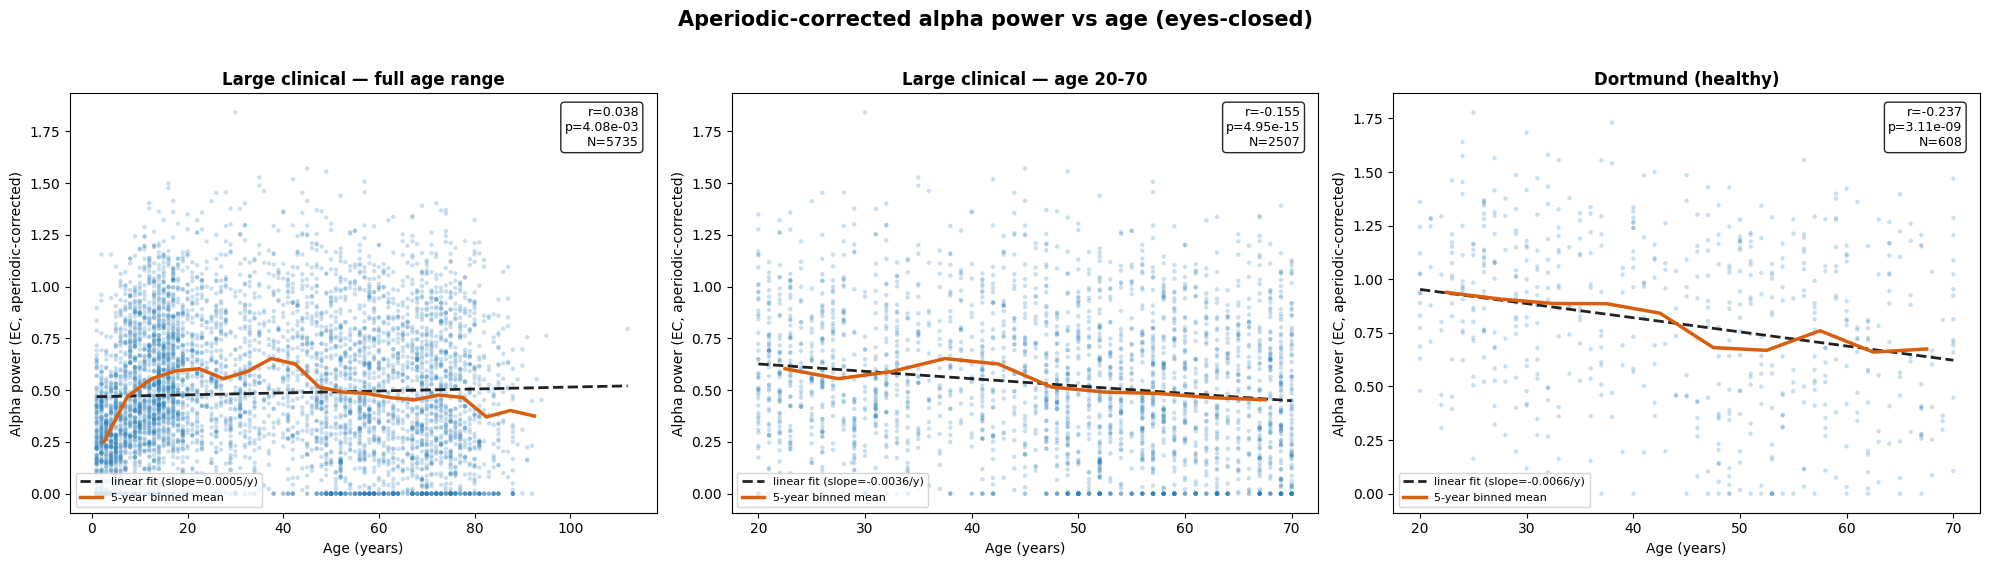

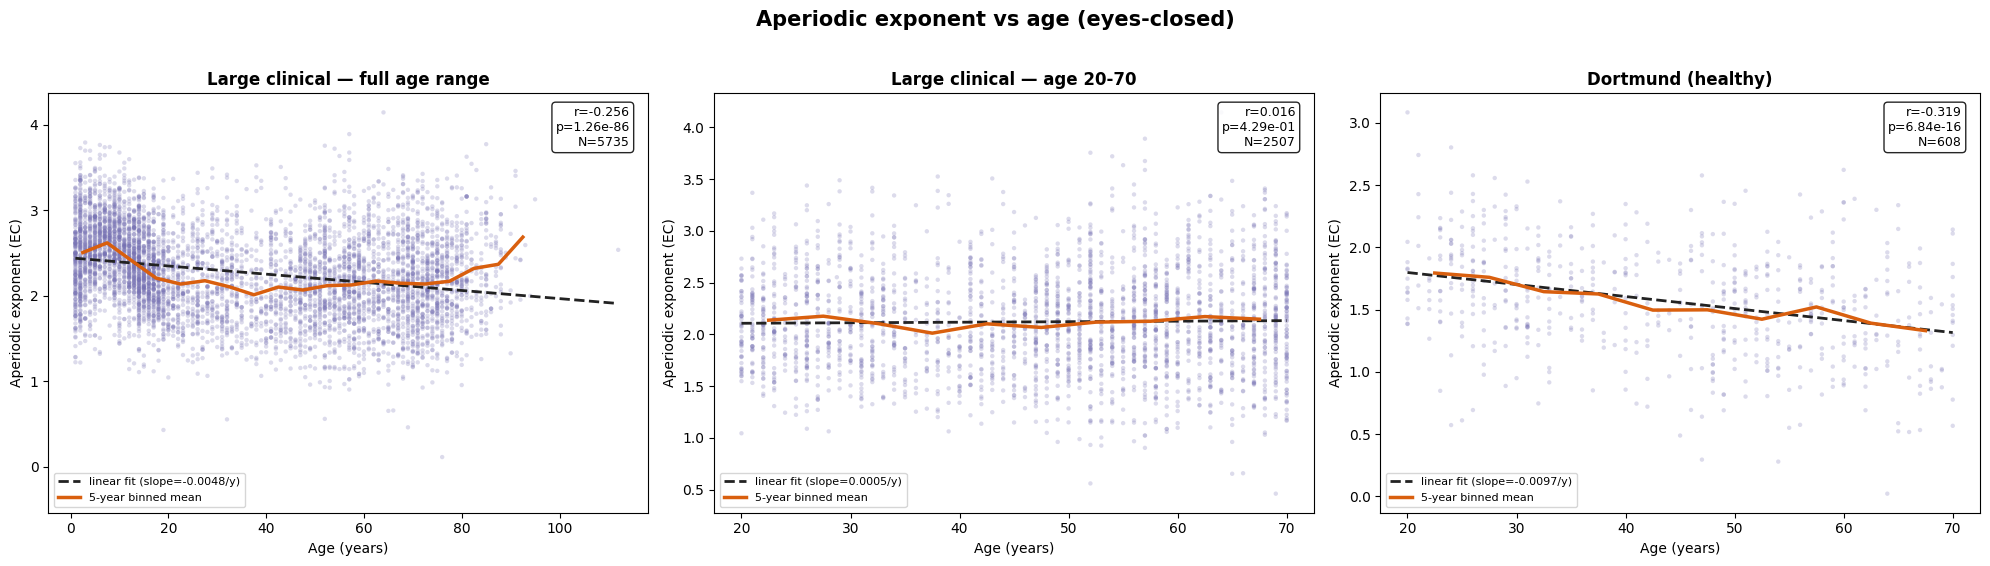


Headline slopes (eyes-closed):

alpha_power_ec vs age:
  clinical full   : slope=0.00047/y, r=0.038, p=4.08e-03, N=5735
  clinical 20-70  : slope=-0.00356/y, r=-0.155, p=4.95e-15, N=2507
  Dortmund        : slope=-0.00660/y, r=-0.237, p=3.11e-09, N=608

exponent_ec vs age:
  clinical full   : slope=-0.00477/y, r=-0.256, p=1.26e-86, N=5735
  clinical 20-70  : slope=0.00051/y, r=0.016, p=4.29e-01, N=2507
  Dortmund        : slope=-0.00965/y, r=-0.319, p=6.84e-16, N=608


In [ ]:
import matplotlib.pyplot as plt
clin = pd.read_csv(APERIODIC_CLINICAL_CSV)
dort = pd.read_csv(APERIODIC_DORTMUND_CSV)
_conn = pd.read_csv(OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv")
_cohort_ids = set(_conn[(_conn.n_montage_ch == 19) & (_conn.n_roi_ch == 7) &
                        (_conn.n_epochs >= 10) & _conn.age.notna()]["subject"])
clin = clin[clin["subject"].isin(_cohort_ids)].copy()
print(f"[cohort] clinical aperiodic restricted to {len(clin)} subjects (from full file)")
clin_2070 = clin[clin["age"].between(20, 70)]

def panel(ax, df, ycol, title, ylabel, color="#2c7fb8"):
    d = df.dropna(subset=["age", ycol]); d = d[np.isfinite(d[ycol])]
    if len(d) < 3:
        ax.set_title(title + " (insufficient data)"); return
    ax.scatter(d["age"], d[ycol], s=10, alpha=0.25, color=color, edgecolor="none")
    sl, ic, r, p, se = stats.linregress(d["age"], d[ycol])
    xs = np.linspace(d["age"].min(), d["age"].max(), 100)
    ax.plot(xs, ic + sl*xs, "--", color="#222", lw=2, label=f"linear fit (slope={sl:.4f}/y)")
    bins = np.arange(np.floor(d["age"].min()/5)*5, np.ceil(d["age"].max()/5)*5 + 5, 5)
    cats = pd.cut(d["age"], bins)
    gm = d.groupby(cats, observed=False)[ycol].mean(); gc = (bins[:-1] + bins[1:]) / 2
    ax.plot(gc, gm.values, "-", color="#d95f0e", lw=2.5, label="5-year binned mean")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Age (years)"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc="lower left")
    ax.text(0.97, 0.97, f"r={r:.3f}\np={p:.2e}\nN={len(d)}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
panel(axes[0], clin,      "alpha_power_ec", "Large clinical — full age range", "Alpha power (EC, aperiodic-corrected)")
panel(axes[1], clin_2070, "alpha_power_ec", "Large clinical — age 20-70",      "Alpha power (EC, aperiodic-corrected)")
panel(axes[2], dort,      "alpha_power_ec", "Dortmund (healthy)",              "Alpha power (EC, aperiodic-corrected)")
plt.suptitle("Aperiodic-corrected alpha power vs age (eyes-closed)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig(OUT_ROOT / f"alpha_power_vs_age_{EPOCH_TAG}.png", dpi=130, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
panel(axes[0], clin,      "exponent_ec", "Large clinical — full age range", "Aperiodic exponent (EC)", color="#7570b3")
panel(axes[1], clin_2070, "exponent_ec", "Large clinical — age 20-70",      "Aperiodic exponent (EC)", color="#7570b3")
panel(axes[2], dort,      "exponent_ec", "Dortmund (healthy)",              "Aperiodic exponent (EC)", color="#7570b3")
plt.suptitle("Aperiodic exponent vs age (eyes-closed)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig(OUT_ROOT / f"aperiodic_exponent_vs_age_{EPOCH_TAG}.png", dpi=130, bbox_inches="tight"); plt.show()

print("\nHeadline slopes (eyes-closed):")
for metric in ["alpha_power_ec", "exponent_ec"]:
    print(f"\n{metric} vs age:")
    for nm, d in [("clinical full", clin), ("clinical 20-70", clin_2070), ("Dortmund", dort)]:
        dd = d.dropna(subset=["age", metric])
        if len(dd) >= 3:
            sl, ic, r, p, se = stats.linregress(dd["age"], dd[metric])
            print(f"  {nm:16s}: slope={sl:.5f}/y, r={r:.3f}, p={p:.2e}, N={len(dd)}")

[cohort] clinical aperiodic restricted to 6012 subjects (from full file)


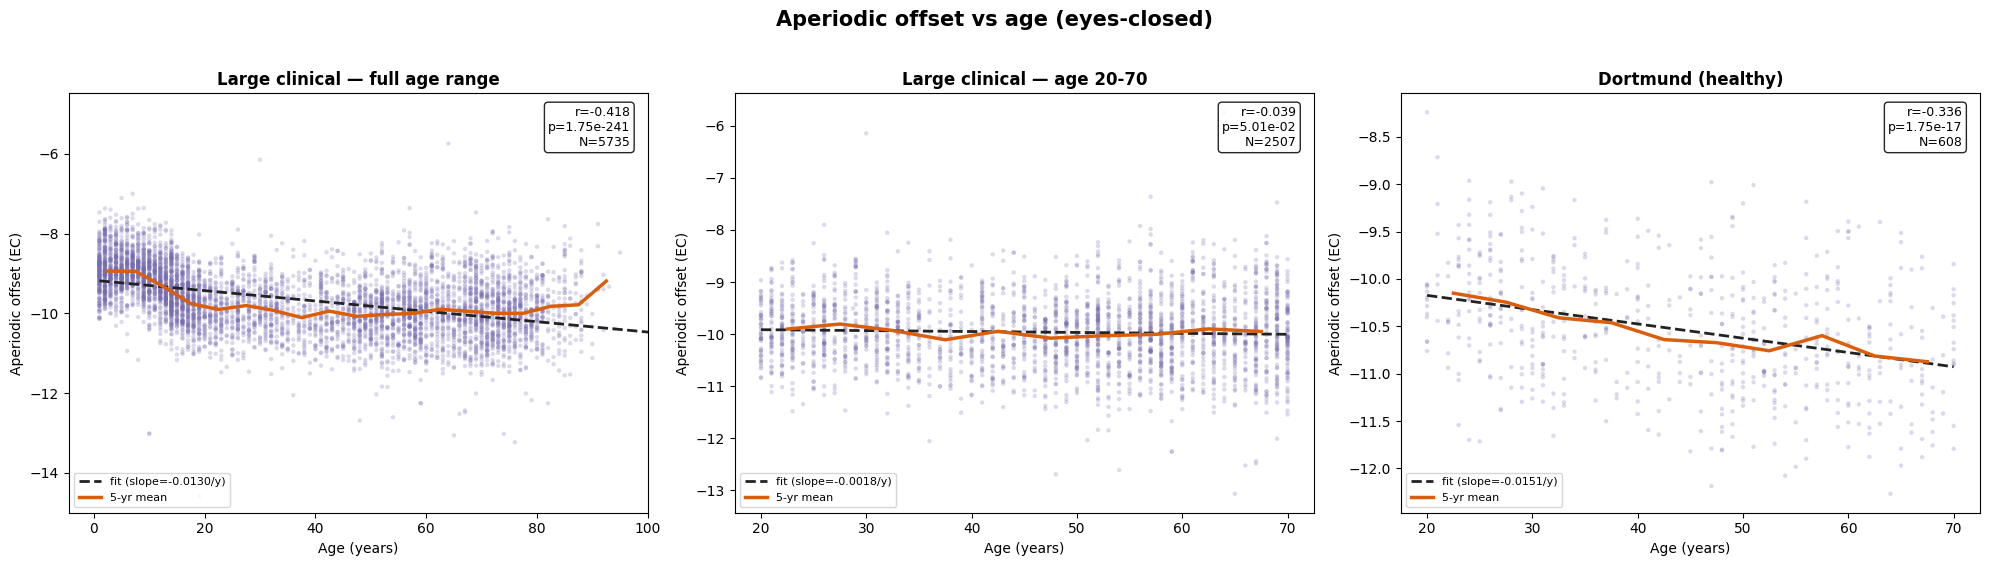


metric       eye group              slope/yr       r          p      N
----------------------------------------------------------------------
offset       EC  clinical full      -0.01298  -0.418  1.75e-241   5735
offset       EC  clinical 20-70     -0.00177  -0.039   5.01e-02   2507
offset       EC  Dortmund           -0.01508  -0.336   1.75e-17    608
offset       EO  clinical full      -0.01141  -0.389  2.67e-207   5740
offset       EO  clinical 20-70     +0.00133  +0.029   1.44e-01   2536
offset       EO  Dortmund           -0.01094  -0.303   2.12e-14    608

exponent     EC  clinical full      -0.00477  -0.256   1.26e-86   5735
exponent     EC  clinical 20-70     +0.00051  +0.016   4.29e-01   2507
exponent     EC  Dortmund           -0.00965  -0.319   6.84e-16    608
exponent     EO  clinical full      -0.00401  -0.226   3.48e-67   5740
exponent     EO  clinical 20-70     +0.00211  +0.074   1.89e-04   2536
exponent     EO  Dortmund           -0.00809  -0.296   9.58e-14    608

alp

In [ ]:
# APERIODIC — the missing OFFSET figure + a full summary table.
# Reads the two aperiodic CSVs already written. Nothing slow reruns.

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
clin = pd.read_csv(APERIODIC_CLINICAL_CSV)
dort = pd.read_csv(APERIODIC_DORTMUND_CSV)
_conn = pd.read_csv(OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv")
_cohort_ids = set(_conn[(_conn.n_montage_ch == 19) & (_conn.n_roi_ch == 7) &
                        (_conn.n_epochs >= 10) & _conn.age.notna()]["subject"])
clin = clin[clin["subject"].isin(_cohort_ids)].copy()
print(f"[cohort] clinical aperiodic restricted to {len(clin)} subjects (from full file)")
clin_2070 = clin[clin.age.between(20, 70)]
def _panel(ax, df, ycol, title, ylabel, color="#756bb1"):
    d = df.dropna(subset=["age", ycol]); d = d[np.isfinite(d[ycol])]
    if len(d) < 5: ax.set_title(title + " (insufficient)"); return
    ax.scatter(d["age"], d[ycol], s=10, alpha=0.25, color=color, edgecolor="none")
    sl, ic, r, p, se = stats.linregress(d["age"], d[ycol])
    xs = np.linspace(d["age"].min(), d["age"].max(), 100)
    ax.plot(xs, ic + sl*xs, "--", color="#222", lw=2, label=f"fit (slope={sl:.4f}/y)")
    bins = np.arange(np.floor(d["age"].min()/5)*5, np.ceil(d["age"].max()/5)*5 + 5, 5)
    gm = d.groupby(pd.cut(d["age"], bins), observed=False)[ycol].mean()
    ax.plot((bins[:-1]+bins[1:])/2, gm.values, "-", color="#d95f0e", lw=2.5, label="5-yr mean")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Age (years)"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc="lower left")
    ax.text(0.97, 0.97, f"r={r:.3f}\np={p:.2e}\nN={len(d)}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
_panel(axes[0], clin,      "offset_ec", "Large clinical — full age range", "Aperiodic offset (EC)")
_panel(axes[1], clin_2070, "offset_ec", "Large clinical — age 20-70",      "Aperiodic offset (EC)")
_panel(axes[2], dort,      "offset_ec", "Dortmund (healthy)",              "Aperiodic offset (EC)")

axes[0].set_ylim(bottom=-15)
axes[0].set_xlim(right=100)

plt.suptitle("Aperiodic offset vs age (eyes-closed)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_ROOT / f"aperiodic_offset_vs_age_{EPOCH_TAG}.png", dpi=130, bbox_inches="tight")
plt.show()
def _fit(df, col, lo=None, hi=None):
    d = df.dropna(subset=["age", col]); d = d[np.isfinite(d[col])]
    if lo is not None: d = d[d.age.between(lo, hi)]
    if len(d) < 5: return None
    sl, ic, r, p, se = stats.linregress(d["age"], d[col]); return sl, r, p, len(d)
print(f"\n{'metric':<13}{'eye':<4}{'group':<16}{'slope/yr':>11}{'r':>8}{'p':>11}{'N':>7}")
print("-"*70)
for metric in ["offset", "exponent", "alpha_power"]:
    for eye in ["ec", "eo"]:
        col = f"{metric}_{eye}"
        for nm, d_, lo, hi in [("clinical full", clin, None, None),
                               ("clinical 20-70", clin, 20, 70),
                               ("Dortmund", dort, None, None)]:
            if col not in d_.columns: continue
            r = _fit(d_, col, lo, hi)
            if r: print(f"{metric:<13}{eye.upper():<4}{nm:<16}{r[0]:>+11.5f}{r[1]:>+8.3f}{r[2]:>11.2e}{r[3]:>7d}")
    print()

In [ ]:
# Aperiodic LMM + EC/EO comparison — runs on the CACHED CSVs, no rerun.

import pandas as pd, numpy as np, warnings
import statsmodels.formula.api as smf
from scipy import stats
warnings.filterwarnings("ignore")

def _mixed(d, ec, eo):
    d = d.dropna(subset=[ec, eo, "age"]).copy()
    if "subject" not in d.columns: d["subject"] = np.arange(len(d))
    d["age_c"] = d["age"] - d["age"].mean()
    long = pd.melt(d, id_vars=["subject", "age_c"], value_vars=[ec, eo], var_name="cond", value_name="y")
    long["eye"] = np.where(long["cond"] == ec, "EC", "EO")
    m = smf.mixedlm("y ~ C(eye, Treatment('EO')) * age_c", long, groups=long["subject"]).fit()
    f, p, ci = m.params, m.pvalues, m.conf_int()
    k = "C(eye, Treatment('EO'))[T.EC]"; ki = k + ":age_c"
    return f[k], ci.loc[k, 0], ci.loc[k, 1], p[k], p[ki]

_conn = pd.read_csv(OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv")
_cohort_ids = set(_conn[(_conn.n_montage_ch == 19) & (_conn.n_roi_ch == 7) &
                        (_conn.n_epochs >= 10) & _conn.age.notna()]["subject"])
for name, path in [("LARGE CLINICAL", APERIODIC_CLINICAL_CSV), ("DORTMUND", APERIODIC_DORTMUND_CSV)]:
    df = pd.read_csv(path)
    if name == "LARGE CLINICAL":
        df = df[df["subject"].isin(_cohort_ids)].copy()   # match the 6012 cohort
    print(f"\n{'='*70}\n{name}  (N={len(df)})\n{'='*70}")
    for metric in ["exponent", "offset", "alpha_power"]:
        ec, eo = f"{metric}_ec", f"{metric}_eo"
        if ec not in df.columns: continue
        for label, sub in [("full", df), ("20-70", df[df.age.between(20, 70)])]:
            d = sub.dropna(subset=[ec, eo, "age"])
            if len(d) < 10: continue
            _, wp = stats.wilcoxon(d[ec], d[eo])
            eff, lo, hi, ep, ip = _mixed(d, ec, eo)
            print(f"  {metric:11s} {label:5s} N={len(d):5d}  EC={d[ec].mean():+.4f} EO={d[eo].mean():+.4f}  Wilcoxon p={wp:.1e}")
            print(f"                            LMM eye(EC-EO)={eff:+.4f} [{lo:+.4f},{hi:+.4f}] p={ep:.1e}  interaction p={ip:.1e}")


LARGE CLINICAL  (N=6012)
  exponent    full  N= 5463  EC=+2.2473 EO=+1.6673  Wilcoxon p=0.0e+00
                            LMM eye(EC-EO)=+0.5800 [+0.5693,+0.5907] p=0.0e+00  interaction p=2.2e-07
  exponent    20-70 N= 2387  EC=+2.0913 EO=+1.5191  Wilcoxon p=0.0e+00
                            LMM eye(EC-EO)=+0.5722 [+0.5560,+0.5885] p=0.0e+00  interaction p=7.3e-05
  offset      full  N= 5463  EC=-9.6600 EO=-10.1482  Wilcoxon p=0.0e+00
                            LMM eye(EC-EO)=+0.4882 [+0.4741,+0.5023] p=0.0e+00  interaction p=1.8e-09
  offset      20-70 N= 2387  EC=-9.9881 EO=-10.4709  Wilcoxon p=0.0e+00
                            LMM eye(EC-EO)=+0.4828 [+0.4652,+0.5003] p=0.0e+00  interaction p=3.5e-08
  alpha_power full  N= 5463  EC=+0.4880 EO=+0.3191  Wilcoxon p=0.0e+00
                            LMM eye(EC-EO)=+0.1689 [+0.1635,+0.1743] p=0.0e+00  interaction p=2.8e-02
  alpha_power 20-70 N= 2387  EC=+0.5334 EO=+0.3371  Wilcoxon p=4.2e-297
                            LMM eye

In [ ]:
# Aperiodic stats on the SAME cohort as the connectivity (no rerun; reads caches).
import pandas as pd, numpy as np
from scipy import stats
CONN_CSV = OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv"
conn = pd.read_csv(CONN_CSV)
cohort_ids = set(conn[(conn.n_montage_ch == 19) & (conn.n_roi_ch == 7) &
                      (conn.n_epochs >= 10) & conn.age.notna()]["subject"])
ap = pd.read_csv(APERIODIC_CLINICAL_CSV)
apc = ap[ap["subject"].isin(cohort_ids)].copy()
print(f"connectivity cohort: {len(cohort_ids)} | aperiodic restricted to it: {len(apc)} (from {len(ap)})\n")
print("Aperiodic vs age, cohort-matched (slope / r / p / N):")
for metric in ["exponent", "offset", "alpha_power"]:
    for eye in ["ec", "eo"]:
        col = f"{metric}_{eye}"
        for label, sub in [("full", apc), ("20-70", apc[apc.age.between(20, 70)])]:
            d = sub.dropna(subset=[col, "age"])
            if len(d) < 10: continue
            sl, _, r, p, _ = stats.linregress(d.age, d[col])
            print(f"  {metric:11s} {eye.upper()} {label:5s}: slope={sl:+.5f} r={r:+.3f} p={p:.1e} N={len(d)}")

connectivity cohort: 6012 | aperiodic restricted to it: 6012 (from 6859)

Aperiodic vs age, cohort-matched (slope / r / p / N):
  exponent    EC full : slope=-0.00477 r=-0.256 p=1.3e-86 N=5735
  exponent    EC 20-70: slope=+0.00051 r=+0.016 p=4.3e-01 N=2507
  exponent    EO full : slope=-0.00401 r=-0.226 p=3.5e-67 N=5740
  exponent    EO 20-70: slope=+0.00211 r=+0.074 p=1.9e-04 N=2536
  offset      EC full : slope=-0.01298 r=-0.418 p=1.7e-241 N=5735
  offset      EC 20-70: slope=-0.00177 r=-0.039 p=5.0e-02 N=2507
  offset      EO full : slope=-0.01141 r=-0.389 p=2.7e-207 N=5740
  offset      EO 20-70: slope=+0.00133 r=+0.029 p=1.4e-01 N=2536
  alpha_power EC full : slope=+0.00047 r=+0.038 p=4.1e-03 N=5735
  alpha_power EC 20-70: slope=-0.00356 r=-0.155 p=4.9e-15 N=2507
  alpha_power EO full : slope=+0.00037 r=+0.041 p=1.8e-03 N=5740
  alpha_power EO 20-70: slope=-0.00228 r=-0.141 p=8.5e-13 N=2536


In [ ]:
import pandas as pd, numpy as np, warnings
import statsmodels.formula.api as smf
from scipy import stats
warnings.filterwarnings("ignore")

CONN_CSV = OUT_ROOT / f"clinical_connectivity_{EPOCH_TAG}.csv"
conn = pd.read_csv(CONN_CSV)
cohort_ids = set(conn[(conn.n_montage_ch == 19) & (conn.n_roi_ch == 7) &
                      (conn.n_epochs >= 10) & conn.age.notna()]["subject"])
apc = pd.read_csv(APERIODIC_CLINICAL_CSV)
apc = apc[apc["subject"].isin(cohort_ids)].copy()
print(f"{'='*70}\nLARGE CLINICAL — aperiodic vs age (cohort-matched, N={len(apc)})\n{'='*70}")
for metric in ["exponent", "offset", "alpha_power"]:
    for eye in ["ec", "eo"]:
        col = f"{metric}_{eye}"
        for label, sub in [("full", apc), ("20-70", apc[apc.age.between(20, 70)])]:
            d = sub.dropna(subset=[col, "age"])
            if len(d) < 10: continue
            sl, _, r, p, _ = stats.linregress(d.age, d[col])
            print(f"  {metric:11s} {eye.upper()} {label:5s}: slope={sl:+.5f} r={r:+.3f} p={p:.1e} N={len(d)}")

def _mixed(d, ec, eo):
    d = d.dropna(subset=[ec, eo, "age"]).copy()
    if "subject" not in d.columns: d["subject"] = np.arange(len(d))
    d["age_c"] = d["age"] - d["age"].mean()
    long = pd.melt(d, id_vars=["subject", "age_c"], value_vars=[ec, eo], var_name="cond", value_name="y")
    long["eye"] = np.where(long["cond"] == ec, "EC", "EO")
    m = smf.mixedlm("y ~ C(eye, Treatment('EO')) * age_c", long, groups=long["subject"]).fit()
    f, p, ci = m.params, m.pvalues, m.conf_int()
    k = "C(eye, Treatment('EO'))[T.EC]"; ki = k + ":age_c"
    return f[k], ci.loc[k, 0], ci.loc[k, 1], p[k], p[ki]

apd = pd.read_csv(APERIODIC_DORTMUND_CSV)
print(f"\n{'='*70}\nDORTMUND — aperiodic (ground-truth EC/EO, N={len(apd)})\n{'='*70}")
for metric in ["exponent", "offset", "alpha_power"]:
    ec, eo = f"{metric}_ec", f"{metric}_eo"
    d = apd.dropna(subset=[ec, eo, "age"])
    if len(d) < 10: continue
    _, wp = stats.wilcoxon(d[ec], d[eo]); eff, lo, hi, ep, ip = _mixed(d, ec, eo)
    s_ec, _, r_ec, p_ec, _ = stats.linregress(d.age, d[ec])
    print(f"  {metric:11s} N={len(d):4d}  EC={d[ec].mean():+.4f} EO={d[eo].mean():+.4f}  EC-EO Wilcoxon p={wp:.1e}")
    print(f"               LMM eye(EC-EO)={eff:+.4f} [{lo:+.4f},{hi:+.4f}] p={ep:.1e} | EC vs age: r={r_ec:+.3f} p={p_ec:.1e}")

LARGE CLINICAL — aperiodic vs age (cohort-matched, N=6012)
  exponent    EC full : slope=-0.00477 r=-0.256 p=1.3e-86 N=5735
  exponent    EC 20-70: slope=+0.00051 r=+0.016 p=4.3e-01 N=2507
  exponent    EO full : slope=-0.00401 r=-0.226 p=3.5e-67 N=5740
  exponent    EO 20-70: slope=+0.00211 r=+0.074 p=1.9e-04 N=2536
  offset      EC full : slope=-0.01298 r=-0.418 p=1.7e-241 N=5735
  offset      EC 20-70: slope=-0.00177 r=-0.039 p=5.0e-02 N=2507
  offset      EO full : slope=-0.01141 r=-0.389 p=2.7e-207 N=5740
  offset      EO 20-70: slope=+0.00133 r=+0.029 p=1.4e-01 N=2536
  alpha_power EC full : slope=+0.00047 r=+0.038 p=4.1e-03 N=5735
  alpha_power EC 20-70: slope=-0.00356 r=-0.155 p=4.9e-15 N=2507
  alpha_power EO full : slope=+0.00037 r=+0.041 p=1.8e-03 N=5740
  alpha_power EO 20-70: slope=-0.00228 r=-0.141 p=8.5e-13 N=2536

DORTMUND — aperiodic (ground-truth EC/EO, N=608)
  exponent    N= 608  EC=+1.5658 EO=+1.5907  EC-EO Wilcoxon p=3.8e-01
               LMM eye(EC-EO)=-0.0249 [